In [1]:
import jax 
from jax import numpy as jnp
from jax.numpy import linalg as jnpla
from jax.scipy import linalg as jspla
from jax import random as jrnd
from jax import tree_util as jtu

from matplotlib import pyplot as plt

from time import time
from collections.abc import Callable

jax.config.update('jax_enable_x64', True)

In [ ]:
import jax
from jax import numpy as jnp
from jax import random as jrnd
from jax import tree_util as jtu

from collections.abc import Callable

from numerics.spectral import *
from numerics.sobol import *

# Legendre roots
def rw_GL(k:int, tol:float = 1e-14):
    """
    Generates k roots from Legendre polynomials using Newton's method. 

    Parameters
    ----------
    k : int
        Number of roots. 
    tol : float, optional
        Absoulte tolerance for Newton-Raphson

    Returns
    -------
    jax.Array
        Array of shape (k) containing roots of kth Legendre polynomial.
    """
    # uv_psi autoscales x without a domain input, so here's our domain
    D = jnp.array([-1., 1.])

    # Initial Cheb guess
    k_range = jnp.arange(k) + 1
    x0 = jnp.cos(jnp.pi * (4 * k_range - 1) / (4 * k + 2))[::-1]
    # Each time, k_exc will be k + 1 so we can grab the kth polynomial.
    P_km1, P_k = uv_psi(x0, basis = 'P', k_exc = k + 1)[:, -2:].T
    init_state = (x0, P_km1, P_k)
    
    # Newton raphson
    def body_fn(state):
        x, P_km1, P_k = state
        # Analytical derivative
        dPdx_k = k * (P_km1 - x * P_k) / (1 - x ** 2)
        x = x - (P_k / dPdx_k)
        P = uv_psi(x, basis = 'P', k_exc = k + 1)
        P_km1, P_k= P[:, -2:].T
        return (x, P_km1, P_k)
    
    def cond_fn(state):
        x, P_nm1, P_n = state
        return jnp.all(jnp.abs(P_n) > tol)
    
    # Run
    x, P_nm1, P_n, = lax.while_loop(cond_fn, body_fn, init_state)
    w = (2 * (1 - x ** 2)) / (k ** 2 * P_nm1 ** 2)

    return x, w

# Multivariate roots and weights
def mvrw_GL(dim:int, a:float|jax.Array, b:float|jax.Array, ord:int):
    """
    Tensor-product GLQ rule.

    Parameters
    ----------
    dim : int
        Number of dimensions for the multivariate quadrature (must be >= 1).
    a, b : float
        Endpoints of the target integration interval [a, b] for each coordinate.
        Coordinates are affinely mapped from the reference interval [-1, 1].
    ord : int
        Number of 1‑D Gauss–Legendre nodes/weights (as produced by rw_P).
        The total number of multivariate nodes will be n**dim.

    Returns
    -------
    rr : jax.numpy.ndarray, shape (ord**dim, dim)
    ww : jax.numpy.ndarray, shape (ord**dim,)
    """
    
    # Get Legendre RW
    r, w = rw_GL(ord)
    # Cartesian product
    rr = jnp.stack(jnp.meshgrid(*[r] * dim), axis = -1).reshape(ord ** dim, dim)
    ww = jnp.stack(jnp.meshgrid(*[w] * dim), axis = -1).reshape(ord ** dim, dim)
    # Stretch and scale
    rr = rr * (b - a) / 2 + (a + b) / 2
    ww = ww * (b - a) / 2
    # Prod roots
    ww = jnp.prod(ww, axis = 1)
    return rr, ww

def mvrw_MC(dim:int, a:float|jax.Array, b:float|jax.Array, ord:int, key:jax.Array):
    rr = jrnd.uniform(key, (ord ** dim, dim), minval = a, maxval = b)
    ww = jnp.prod(b - a) / (ord ** dim)
    return rr, ww

def mvrw_QMC(dim:int, a:float|jax.Array, b:float|jax.Array, n:int):
    """Sobol points and rectangular weights for a rectangular domain.

    Parameters
    ----------
    dim : int
        Number of dimensions.
    a : array-like or scalar
        Lower bound(s) of the domain. Must be broadcastable to shape (dim,).
    b : array-like or scalar
        Upper bound(s) of the domain. Must be broadcastable to shape (dim,).
    n : int
        Number of subdivisions per dimension; total samples produced = is 2^(int(log2(n))).

    Returns
    -------
    rr : jnp.ndarray, shape (n**dim, dim)
        Sobol points scaled to the hyper-rectangle [a, b].
    ww : jnp.ndarray, shape (n**dim,)
        Constant weights equal to volume_of_domain / (n ** dim).
    """
    # Straightforward
    log2n = int(jnp.log2(n))
    rr = sobol(dim, log2n)
    n = rr.shape[0]
    rr = rr * (b - a) + a
    w = jnp.prod(b - a) / (n)
    ww = jnp.full(n, w)
    return rr, ww

## UNUSED
def mvrw_GLQMC(dim:int, a:float|jax.Array, b:float|jax.Array, n:int, m:int = 50):
    """
    Compute multivariate quadrature nodes and product weights by interpolating
    1D Gauss–Legendre nodes/weights onto Sobol quasi-random coordinates and
    scaling to rectangular domain.

    Parameters
    ----------
    dim : int
        Number of dimensions (columns) for the multivariate points.
    a, b : float, jax.Array
        Interval endpoints used to scale nodes and weights. If jax.Array, must be
        of shape (dim,).
    n : int
        Number of Sobol points per dimension (total number produced: n ** dim).
    m : int
        Number of GL roots/weights for linear interpolation.

    Returns
    -------
    rr : jnp.ndarray
        Array of shape (n, dim) containing mapped abscissas in [a, b] for each
        Sobol sample and dimension.
    ww : jnp.ndarray
        1D array of length n containing the product (multivariate) weights
        corresponding to each row of rr, scaled for the interval [a, b].
    """
    # interpolation space
    i = jnp.linspace(-1., 1., m)
    # GL roots and weights for interpolation
    r_GL, w_GL = rw_GL(m)
    # Sobol roots to stretch
    r_sobol, _ = mvrw_QMC(dim, -1., 1., n)
    n = r_sobol.shape[0]
    # Treat data as (i, r_GL) and (i, w_GL) and interpolate values at sobol points
    rr = jax.vmap(jtu.Partial(jnp.interp, xp = i, fp = r_GL), in_axes = 1, out_axes = 1)(r_sobol)
    ww = jax.vmap(jtu.Partial(jnp.interp, xp = i, fp = w_GL), in_axes = 1, out_axes = 1)(r_sobol)
    # Stretch and scale
    rr = rr * (b - a) / 2 + (a + b) / 2
    ww = ww * (b - a) / 2
    # prod roots, scale for difference in point #
    ww = jnp.prod(ww, axis = 1) * (m / n)
    return rr, ww

In [ ]:
# Half a bump function
def smoothstep(x, r):
    xmr = x - r
    bump = jnp.exp(1 / ((xmr ** 2) / (r ** 2) - 1)) * jnp.e
    cond0 = -x < 0
    cond1 = xmr < 0
    step0 = jnp.where(cond0, bump, 0.)
    step1 = jnp.where(cond1, step0, 1.)
    return step1

# 1d vignette
def v1d(x:jax.Array, r_rel:float, b_rel:float):
    x_range = x.max() - x.min()
    a = x_range * r_rel
    b = x_range * b_rel
    lowstep = smoothstep(x - x.min() - b_rel, a)
    histep = smoothstep(-x + x.max() - b_rel, a)
    return lowstep * histep

# N-d vignette
def fn_vnd(X:jax.Array, r_rel:float, h:float, x0_rel:float):
    full = jax.vmap(v1d, in_axes = (1, None, None), out_axes = 1)(X, r_rel, h, x0_rel)
    return jnp.prod(full, axis = 1)

# RBF Kernels
def phs(r, k:int):
    return r ** k * lax.cond(k % 2 == 0, jnp.log, lambda x: x, r)

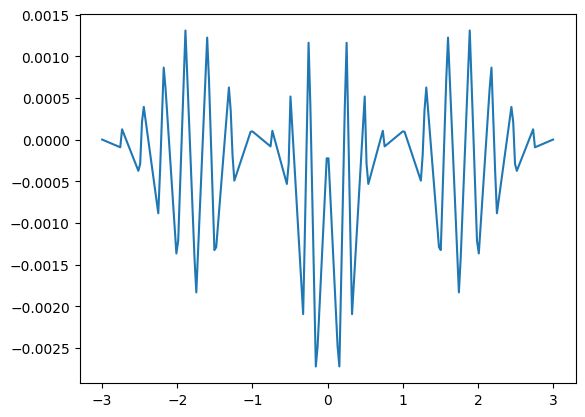

In [ ]:
def vrbfi(f:Callable, a:float|jax.Array, b:float|jax.Array, n:int, engine:str = 'qmc'):
    pass
    # Sample X, y
    # Partition X, y into X[i], y[i], shapes (ni, d), (n,) (Mask different ys to be shape n with nonzero entries of interest)
    # Build I in (n, n)
    I = jnp.eye((n, n))
    # Calculate nn distances for X[0]
    # Update with Phi using nn distances from X[0] as radii
    # Solve for masked y[0]
    # For each iteration:
        # Build RBF interpolant and solve
        # Calculate gradients, apply vignette to keep edges
        # Take X[i] + (scaled grad based on nn dists)
        # Append X[i] to X[0]
        # Update NN dists + everything else using low-rank update

In [5]:
import jax
from jax import numpy as jnp
from jax import random as jrnd
from jax import tree_util as jtu

from collections.abc import Callable

from numerics.spectral import *
from numerics.sobol import *

# Legendre roots
def rw_GL(k:int, max_iters:int = 50, tol:float = 1e-12):
    """
    Generates k roots from Legendre polynomials using Newton's method. 

    Parameters
    ----------
    k : int
        Number of roots. 
    max_iters : int, default 50
        Maximum number of Newton-Raphson iterations
    tol : float, default 1e-12
        Absoulte tolerance for Newton-Raphson

    Returns
    -------
    jax.Array
        Array of shape (k) containing roots of kth Legendre polynomial.
    """
    # uv_psi autoscales x without a domain input, so here's our domain
    D = jnp.array([-1., 1.])

    # Initial Cheb guess
    k_range = jnp.arange(k) + 1
    x0 = jnp.cos(jnp.pi * (4 * k_range - 1) / (4 * k + 2))[::-1]
    # Each time, k_exc will be k + 1 so we can grab the kth polynomial.
    P_km1, P_k = uv_psi(x0, basis = 'P', k_exc = k + 1)[:, -2:].T
    init_state = (x0, P_km1, P_k, 0)
    
    # Newton raphson root finding
    def body_fn(state):
        x, P_km1, P_k, i = state
        # Analytical derivative
        dPdx_k = k * (P_km1 - x * P_k) / (1 - x ** 2)
        x = x - (P_k / dPdx_k)
        P = uv_psi(x, basis = 'P', k_exc = k + 1)
        P_km1, P_k= P[:, -2:].T
        return (x, P_km1, P_k, i + 1)
    
    def cond_fn(state):
        x, P_nm1, P_n, i = state
        return jnp.logical_and(jnp.any(jnp.abs(P_n) > tol), i > max_iters)
    
    # Run
    x, P_nm1, P_n, _ = lax.while_loop(cond_fn, body_fn, init_state)
    w = (2 * (1 - x ** 2)) / (k ** 2 * P_nm1 ** 2)

    return x, w

def mvrw_GL(k:int, d:int, a:float|jax.Array, b:float|jax.Array, max_iters:int = 50, tol:float = 1e-12):
    pass